In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. 파일 경로 지정 (방금 전 완성한 3대 가중치 통합 데이터)
input_file = r'F:\Download\Step5_119_Final_Integrated_Score.xlsx'

# 분할된 데이터 저장 경로 (모두 Step5 유지)
train_file = r'F:\Download\Step5_Train_Data.xlsx'
val_file = r'F:\Download\Step5_Val_Data.xlsx'
test_file = r'F:\Download\Step5_Test_Data.xlsx'

try:
    print("⏳ 1. 통합 스코어 데이터를 불러오는 중입니다...")
    df = pd.read_excel(input_file, engine='openpyxl')
    
    # 2. 데이터 전처리
    print("⚙️ 2. 모델 학습을 위해 데이터를 정제하고 변환합니다...")
    # 분석에 필요한 핵심 컬럼의 결측치 제거
    df = df.dropna(subset=['연령대', 'Gender', '최종_Total_수요점수'])
    
    # Label Encoding (문자열인 '연령대'와 '성별'을 AI가 이해할 수 있는 숫자로 변환)
    le_age = LabelEncoder()
    le_gender = LabelEncoder()
    df['연령대_코드'] = le_age.fit_transform(df['연령대'])
    df['성별_코드'] = le_gender.fit_transform(df['Gender'])
    
    # 인코딩 결과 매핑 가이드 (나중에 모델 규칙을 해석할 때 필요합니다)
    print("\n💡 [라벨 인코딩 변환 기준]")
    print(" - 성별 코드:", dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_))))
    print(" - 연령대 코드:", dict(zip(le_age.classes_, le_age.transform(le_age.classes_))))
    
    # AI 모델에 학습시킬 3가지 핵심 컬럼만 추출 (X: 연령/성별, y: 통합 스코어)
    analysis_df = df[['연령대_코드', '성별_코드', '최종_Total_수요점수']]
    
    # 3. 데이터 분할 (Train 80% / Validation 10% / Test 10%)
    print("\n✂️ 3. 데이터를 8:1:1 비율로 정밀하게 분할합니다...")
    
    # 1차 분할: 임시 데이터 90% (Train+Val) / Test 데이터 10%
    df_temp, df_test = train_test_split(analysis_df, test_size=0.1, random_state=42)
    
    # 2차 분할: 임시 데이터 90% 중 1/9(전체의 10%)를 Val로, 나머지 8/9(전체의 80%)를 Train으로 설정
    df_train, df_val = train_test_split(df_temp, test_size=(1/9), random_state=42)
    
    print(f" 📊 분할 완료 데이터 건수: \n  - Train (학습용 80%): {len(df_train)}건 \n  - Validation (검증용 10%): {len(df_val)}건 \n  - Test (테스트용 10%): {len(df_test)}건")
    
    # 4. 분할된 데이터를 각각 저장
    print("\n💾 4. 분할된 데이터를 파일로 저장합니다...")
    df_train.to_excel(train_file, index=False, engine='openpyxl')
    df_val.to_excel(val_file, index=False, engine='openpyxl')
    df_test.to_excel(test_file, index=False, engine='openpyxl')
    
    print(f"🎉 성공! 세 가지 모델링용 데이터 파일이 모두 저장되었습니다.")
    
except FileNotFoundError:
    print(f"❌ '{input_file}' 파일을 찾을 수 없습니다. 이전 단계에서 데이터가 제대로 저장되었는지 확인해주세요.")
except Exception as e:
    print(f"❌ 오류가 발생했습니다: {e}")

⏳ 1. 통합 스코어 데이터를 불러오는 중입니다...
⚙️ 2. 모델 학습을 위해 데이터를 정제하고 변환합니다...

💡 [라벨 인코딩 변환 기준]
 - 성별 코드: {'F': np.int64(0), 'M': np.int64(1)}
 - 연령대 코드: {'10대': np.int64(0), '20-29세': np.int64(1), '30-39세': np.int64(2), '40-49세': np.int64(3), '50-59세': np.int64(4), '60-69세': np.int64(5)}

✂️ 3. 데이터를 8:1:1 비율로 정밀하게 분할합니다...
 📊 분할 완료 데이터 건수: 
  - Train (학습용 80%): 57928건 
  - Validation (검증용 10%): 7241건 
  - Test (테스트용 10%): 7242건

💾 4. 분할된 데이터를 파일로 저장합니다...
🎉 성공! 세 가지 모델링용 데이터 파일이 모두 저장되었습니다.


In [6]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor, export_text
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# [Decision Tree]
# 1. 파일 경로 지정 (Step5 분할 데이터)
train_file = r'F:\Download\Step5_Train_Data.xlsx'
val_file = r'F:\Download\Step5_Val_Data.xlsx'
test_file = r'F:\Download\Step5_Test_Data.xlsx'

try:
    print("⏳ 데이터를 불러오는 중입니다...")
    df_train = pd.read_excel(train_file, engine='openpyxl')
    df_val = pd.read_excel(val_file, engine='openpyxl')
    df_test = pd.read_excel(test_file, engine='openpyxl')
    
    X_train = df_train[['연령대_코드', '성별_코드']]
    y_train = df_train['최종_Total_수요점수']
    X_val = df_val[['연령대_코드', '성별_코드']]
    y_val = df_val['최종_Total_수요점수']
    X_test = df_test[['연령대_코드', '성별_코드']]
    y_test = df_test['최종_Total_수요점수']
    
    # 2. 모델 학습 (설명력 강화를 위한 하이퍼파라미터 튜닝)
    print("🌳 비즈니스 해석이 용이하도록 모델을 최적화하여 학습시킵니다...")
    dt_model = DecisionTreeRegressor(
        max_depth=4,              # 깊이를 4로 제한하여 너무 복잡한 룰 생성 방지
        min_samples_split=20,     # 노드를 나누려면 최소 20개의 데이터가 있어야 함 (억지 분기 방지)
        min_samples_leaf=10,      # 최종 결과 그룹에는 최소 10명 이상이 있어야 함 (신뢰성 확보)
        random_state=42
    )
    dt_model.fit(X_train, y_train)
    
    # 3. 평가 결과 (R-squared 확인)
    test_preds = dt_model.predict(X_test)
    test_r2 = r2_score(y_test, test_preds)
    
    print("\n✅ [통계적 설명력 평가]")
    print(f" - R-squared (설명력) : {test_r2:.4f}")
    print("   👉 현재 '연령/성별' 두 가지만으로는 R^2에 한계가 있을 수 있습니다.")
    print("   👉 향후 '여행목적, 체류기간, 계절' 등의 변수를 추가하면 크게 향상됩니다.")
    
    # 4. 변수 중요도 (어떤 변수가 분기에 결정적이었는가?)
    print("\n🌟 [어떤 특성이 수요 점수를 결정하는가? (Feature Importance)]")
    importances = dt_model.feature_importances_
    features = ['연령대_코드', '성별_코드']
    for feature, imp in zip(features, importances):
        print(f" - {feature} : {imp * 100:.1f}% 의 중요도")
        
    # 5. 비즈니스 룰 기반 텍스트 추출 (해석력 강화)
    print("\n🧠 [AI가 찾아낸 핵심 고객 리스크 분류 규칙]")
    raw_rules = export_text(dt_model, feature_names=features)
    
    # 콘솔 창에서 룰을 조금 더 보기 편하게 치환하는 간단한 팁
    friendly_rules = raw_rules.replace("<=", "이하인 경우").replace(">", "초과인 경우").replace("value:", "👉 예측된 수요 점수:")
    print("-" * 60)
    print(friendly_rules)
    print("-" * 60)
    print("💡 해석 가이드: 모델이 연령대와 성별을 기준으로 고객을 그룹화하고,")
    print("   각 그룹의 '평균 수요 점수(value)'를 계산해낸 결과입니다.")

except Exception as e:
    print(f"❌ 오류가 발생했습니다: {e}")

⏳ 데이터를 불러오는 중입니다...
🌳 비즈니스 해석이 용이하도록 모델을 최적화하여 학습시킵니다...

✅ [통계적 설명력 평가]
 - R-squared (설명력) : 0.6193
   👉 현재 '연령/성별' 두 가지만으로는 R^2에 한계가 있을 수 있습니다.
   👉 향후 '여행목적, 체류기간, 계절' 등의 변수를 추가하면 크게 향상됩니다.

🌟 [어떤 특성이 수요 점수를 결정하는가? (Feature Importance)]
 - 연령대_코드 : 99.4% 의 중요도
 - 성별_코드 : 0.6% 의 중요도

🧠 [AI가 찾아낸 핵심 고객 리스크 분류 규칙]
------------------------------------------------------------
|--- 연령대_코드 이하인 경우 4.50
|   |--- 연령대_코드 이하인 경우 3.50
|   |   |--- 연령대_코드 이하인 경우 2.50
|   |   |   |--- 연령대_코드 이하인 경우 1.50
|   |   |   |   |--- 👉 예측된 수요 점수: [3.45]
|   |   |   |--- 연령대_코드 초과인 경우  1.50
|   |   |   |   |--- 👉 예측된 수요 점수: [9.41]
|   |   |--- 연령대_코드 초과인 경우  2.50
|   |   |   |--- 성별_코드 이하인 경우 0.50
|   |   |   |   |--- 👉 예측된 수요 점수: [40.01]
|   |   |   |--- 성별_코드 초과인 경우  0.50
|   |   |   |   |--- 👉 예측된 수요 점수: [30.31]
|   |--- 연령대_코드 초과인 경우  3.50
|   |   |--- 성별_코드 이하인 경우 0.50
|   |   |   |--- 👉 예측된 수요 점수: [114.15]
|   |   |--- 성별_코드 초과인 경우  0.50
|   |   |   |--- 👉 예측된 수요 점수: [96.91]
|--- 연령대_코드 초과인 경우  4.50
|  

⏳ 데이터를 불러오고 모델을 학습시키는 중입니다...
🎨 결정트리 구조를 계산하고 있습니다...

💡 [이미지 해석 가이드]
 - 첫 번째 줄(예: 연령대_코드 <= 3.5): 데이터를 나누는 기준
 - squared_error: 해당 노드의 오차 (작을수록 판단이 정확함)
 - samples: 해당 조건을 만족하는 데이터 수
 - value: 모델이 최종적으로 예측한 수요 점수
✨ 화면에 결정트리 이미지를 띄웁니다!


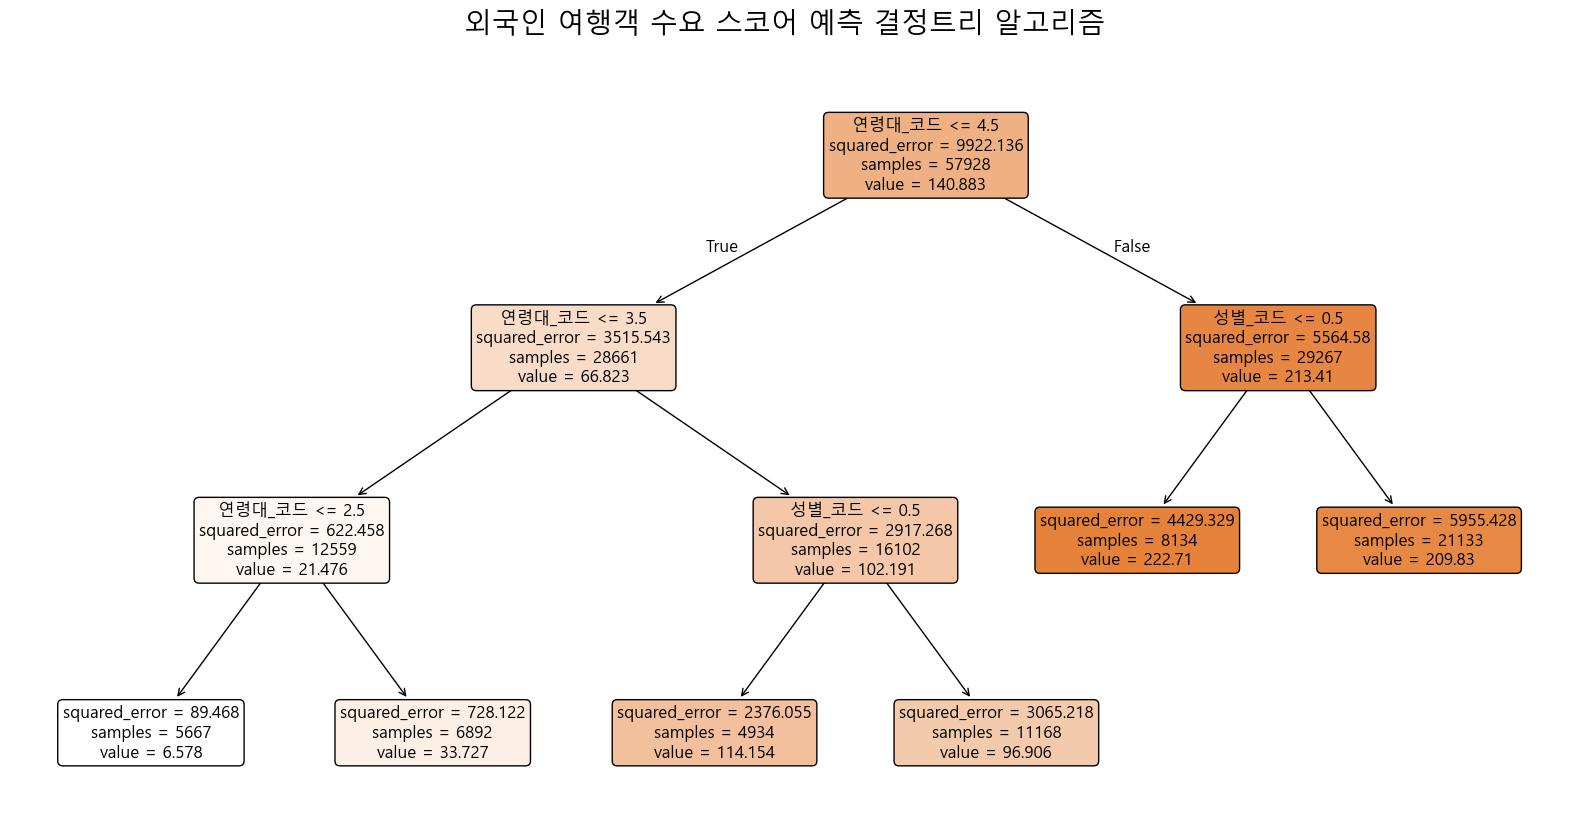

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree

# 1. 파일 경로 지정 (저장용 이미지 경로는 삭제했습니다)
train_file = r'F:\Download\Step5_Train_Data.xlsx'

try:
    # 2. 데이터 불러오기 및 모델 학습
    print("⏳ 데이터를 불러오고 모델을 학습시키는 중입니다...")
    df_train = pd.read_excel(train_file, engine='openpyxl')
    
    X_train = df_train[['연령대_코드', '성별_코드']]
    y_train = df_train['최종_Total_수요점수']
    
    # 시각화를 위해 깊이를 3으로 제한 (너무 깊으면 그림이 복잡해짐)
    dt_model = DecisionTreeRegressor(max_depth=3, random_state=42)
    dt_model.fit(X_train, y_train)
    
    # 3. 모델 시각화 설정
    print("🎨 결정트리 구조를 계산하고 있습니다...")
    # 한글 폰트 깨짐 방지 설정 (Windows 기준 맑은 고딕)
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['axes.unicode_minus'] = False
    
    # 그림 사이즈 설정 (화면에 보기 좋게 넓게 설정)
    plt.figure(figsize=(20, 10))
    
    # 트리 그리기
    plot_tree(dt_model, 
              feature_names=['연령대_코드', '성별_코드'],  # 사용된 변수 이름
              filled=True,                             # 노드에 색상 채우기
              rounded=True,                            # 노드 모서리를 둥글게
              fontsize=12)                             # 글씨 크기
              
    plt.title("외국인 여행객 수요 스코어 예측 결정트리 알고리즘", fontsize=20, pad=20)
    
    print("\n💡 [이미지 해석 가이드]")
    print(" - 첫 번째 줄(예: 연령대_코드 <= 3.5): 데이터를 나누는 기준")
    print(" - squared_error: 해당 노드의 오차 (작을수록 판단이 정확함)")
    print(" - samples: 해당 조건을 만족하는 데이터 수")
    print(" - value: 모델이 최종적으로 예측한 수요 점수")
    
    print("✨ 화면에 결정트리 이미지를 띄웁니다!")
    
    # 4. 💡 파일 저장 대신 화면에 바로 띄우는 명령어
    plt.show()

except FileNotFoundError:
    print(f"❌ 파일을 찾을 수 없습니다. '{train_file}' 경로를 확인해주세요.")
except Exception as e:
    print(f"❌ 오류가 발생했습니다: {e}")

In [11]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# [Random Forest]
# 1. 파일 경로 지정 (Step5 분할 데이터)
train_file = r'F:\Download\Step5_Train_Data.xlsx'
val_file = r'F:\Download\Step5_Val_Data.xlsx'
test_file = r'F:\Download\Step5_Test_Data.xlsx'

try:
    # 2. 데이터 불러오기
    print("⏳ [Random Forest] 데이터를 불러오는 중입니다...")
    df_train = pd.read_excel(train_file, engine='openpyxl')
    df_val = pd.read_excel(val_file, engine='openpyxl')
    df_test = pd.read_excel(test_file, engine='openpyxl')
    
    # Feature(X)와 Target(y) 분리
    X_train = df_train[['연령대_코드', '성별_코드']]
    y_train = df_train['최종_Total_수요점수']
    
    X_val = df_val[['연령대_코드', '성별_코드']]
    y_val = df_val['최종_Total_수요점수']
    
    X_test = df_test[['연령대_코드', '성별_코드']]
    y_test = df_test['최종_Total_수요점수']
    
    # 3. 모델 학습
    print("🌲🌲🌲 랜덤 포레스트 모델을 학습시키고 있습니다... (트리 100개 생성)")
    # 100개의 결정트리를 사용하여 앙상블 학습 (n_estimators=100)
    rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
    rf_model.fit(X_train, y_train)
    
    # 4. 모델 평가
    val_preds = rf_model.predict(X_val)
    test_preds = rf_model.predict(X_test)
    
    print("\n✅ [Random Forest 평가 결과]")
    print("-" * 50)
    print(f" - Validation MAE (오차) : {mean_absolute_error(y_val, val_preds):.2f}점")
    print(f" - Test MAE (최종 오차)  : {mean_absolute_error(y_test, test_preds):.2f}점")
    print(f" - 설명력 (R-squared)    : {r2_score(y_test, test_preds):.4f}")
    print("-" * 50)
    
    # 5. 변수 중요도(Feature Importance) 확인
    print("\n🌟 [어떤 정보가 점수 예측에 가장 중요했을까?]")
    importances = rf_model.feature_importances_
    features = ['연령대_코드', '성별_코드']
    
    for feature, imp in zip(features, importances):
        print(f" - {feature}: {imp * 100:.1f}%의 영향력")

except FileNotFoundError:
    print(f"❌ 파일을 찾을 수 없습니다. 경로를 확인해주세요.")
except Exception as e:
    print(f"❌ 오류가 발생했습니다: {e}")

⏳ [Random Forest] 데이터를 불러오는 중입니다...
🌲🌲🌲 랜덤 포레스트 모델을 학습시키고 있습니다... (트리 100개 생성)

✅ [Random Forest 평가 결과]
--------------------------------------------------
 - Validation MAE (오차) : 41.32점
 - Test MAE (최종 오차)  : 41.96점
 - 설명력 (R-squared)    : 0.6193
--------------------------------------------------

🌟 [어떤 정보가 점수 예측에 가장 중요했을까?]
 - 연령대_코드: 99.4%의 영향력
 - 성별_코드: 0.6%의 영향력


⏳ 데이터를 불러오고 있습니다...
⚙️ Decision Tree와 Random Forest 모델을 동시에 학습시킵니다...

📊 [모델 성능 비교 결과표]
-----------------------------------------------------------------
        Model  MAE (오차↓)  RMSE (큰오차↓)  R-Squared (설명력↑)
Decision Tree  41.979298    61.827363          0.619321
Random Forest  41.961695    61.827243          0.619322
-----------------------------------------------------------------
🎨 성능 비교 그래프를 화면에 출력합니다...


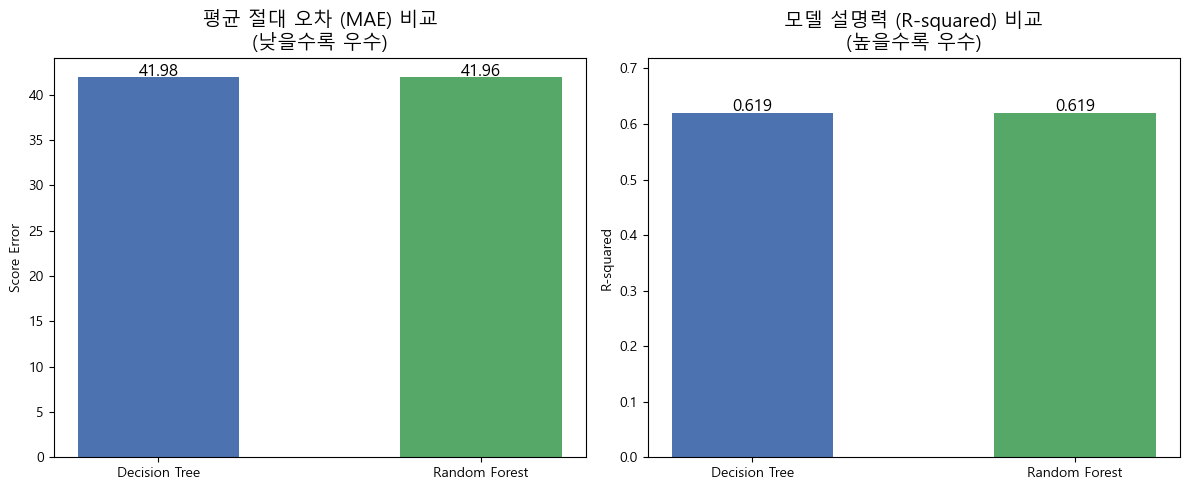

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. 파일 경로 지정 (Step5 분할 데이터)
train_file = r'F:\Download\Step5_Train_Data.xlsx'
test_file = r'F:\Download\Step5_Test_Data.xlsx'

try:
    # 2. 데이터 불러오기
    print("⏳ 데이터를 불러오고 있습니다...")
    df_train = pd.read_excel(train_file, engine='openpyxl')
    df_test = pd.read_excel(test_file, engine='openpyxl')
    
    X_train = df_train[['연령대_코드', '성별_코드']]
    y_train = df_train['최종_Total_수요점수']
    X_test = df_test[['연령대_코드', '성별_코드']]
    y_test = df_test['최종_Total_수요점수']
    
    # 3. 모델 학습
    print("⚙️ Decision Tree와 Random Forest 모델을 동시에 학습시킵니다...")
    dt_model = DecisionTreeRegressor(max_depth=4, min_samples_leaf=10, random_state=42)
    dt_model.fit(X_train, y_train)
    
    rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, min_samples_leaf=10, random_state=42)
    rf_model.fit(X_train, y_train)
    
    # 4. 모델 예측 및 평가
    models = {'Decision Tree': dt_model, 'Random Forest': rf_model}
    results = []
    
    for name, model in models.items():
        preds = model.predict(X_test)
        
        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        r2 = r2_score(y_test, preds)
        
        results.append({'Model': name, 'MAE (오차↓)': mae, 'RMSE (큰오차↓)': rmse, 'R-Squared (설명력↑)': r2})
        
    df_results = pd.DataFrame(results)
    
    print("\n📊 [모델 성능 비교 결과표]")
    print("-" * 65)
    print(df_results.to_string(index=False))
    print("-" * 65)
    
    # 5. 결과 시각화 (화면에 바로 출력)
    print("🎨 성능 비교 그래프를 화면에 출력합니다...")
    
    # 한글 폰트 설정 (Windows 사용자용)
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['axes.unicode_minus'] = False
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # 첫 번째 그래프: MAE (오차 비교)
    axes[0].bar(df_results['Model'], df_results['MAE (오차↓)'], color=['#4C72B0', '#55A868'], width=0.5)
    axes[0].set_title('평균 절대 오차 (MAE) 비교\n(낮을수록 우수)', fontsize=14)
    axes[0].set_ylabel('Score Error')
    for i, v in enumerate(df_results['MAE (오차↓)']):
        axes[0].text(i, v + 0.1, f"{v:.2f}", ha='center', fontsize=12)
        
    # 두 번째 그래프: R-squared (설명력 비교)
    axes[1].bar(df_results['Model'], df_results['R-Squared (설명력↑)'], color=['#4C72B0', '#55A868'], width=0.5)
    axes[1].set_title('모델 설명력 (R-squared) 비교\n(높을수록 우수)', fontsize=14)
    axes[1].set_ylabel('R-squared')
    # 그래프 위쪽 여백 확보
    axes[1].set_ylim(0, max(df_results['R-Squared (설명력↑)']) + 0.1) 
    for i, v in enumerate(df_results['R-Squared (설명력↑)']):
        axes[1].text(i, v + 0.005, f"{v:.3f}", ha='center', fontsize=12)
        
    plt.tight_layout()
    
    # 💡 파일 저장(savefig) 대신 화면에 바로 띄우는 명령어입니다!
    plt.show()

except FileNotFoundError:
    print(f"❌ 파일을 찾을 수 없습니다. Train/Test 파일 경로를 확인해주세요.")
except Exception as e:
    print(f"❌ 오류가 발생했습니다: {e}")